## TODO:
1. rename the columns
2. group the data by the time of the day 
4. find the average consumption

In [41]:
import polars as pl
import pandas as pd
import numpy as np
import pyarrow
import seaborn as sns
import matplotlib.pyplot as plt

### import seaborn as sns

In [42]:
plt.style.use('ggplot')

In [43]:
def edit_column_names(df):
    df=df.rename(lambda col: col.replace('.energy_consumption',''))
    for column in df.columns:
        print (f'{column}, {df[column].dtype}')
    return df

In [44]:
# checking distribution and relationships
def displaying_distribution(df, column_1, ax, f):
    sns.set_theme(style="ticks")
    sns.despine(f)
    sns.histplot(data=df, x="Hours", y=column_1, ax=ax, bins=50)
    ax.set(xlabel="Hours", ylabel=column_1, title=f'{column_1} Distribution in Hours', xticks=list(range(0,24)))

In [45]:
def visualize_distribution(d):
    n_cols=len([n for n in d.dtypes if n ==pl.Float64]) -1
    fig, ax=plt.subplots(n_cols, 1, figsize=(10, 7 * n_cols) )
    indx=0
    for i in d.columns:
        if (d[i].dtype==pl.Float64 and i != 'units_represented'):
            displaying_distribution(d, i, ax[indx], fig)
            indx+=1
    plt.show()

In [47]:
%%time
data=( 
    pl.read_csv('load_profile_data_mobile_home.csv', ignore_errors=True)
    .pipe(edit_column_names).with_columns(
        pl.col('timestamp').str.to_datetime("%Y-%m-%d %H:%M:%S")).with_columns(
        pl.col('timestamp').dt.hour().alias('Hours'))
)

upgrade, Int64
in.state, String
in.geometry_building_type_recs, String
timestamp, String
models_used, Int64
units_represented, Float64
out.electricity.ceiling_fan.kwh, Float64
out.electricity.clothes_dryer.kwh, Float64
out.electricity.clothes_washer.kwh, Float64
out.electricity.cooling_fans_pumps.kwh, Float64
out.electricity.cooling.kwh, Float64
out.electricity.dishwasher.kwh, Float64
out.electricity.freezer.kwh, Float64
out.electricity.heating_fans_pumps.kwh, Float64
out.electricity.heating_hp_bkup.kwh, Float64
out.electricity.heating.kwh, Float64
out.electricity.hot_tub_heater.kwh, Float64
out.electricity.hot_tub_pump.kwh, Float64
out.electricity.hot_water.kwh, Float64
out.electricity.lighting_exterior.kwh, Float64
out.electricity.lighting_garage.kwh, Float64
out.electricity.lighting_interior.kwh, Float64
out.electricity.mech_vent.kwh, Float64
out.electricity.plug_loads.kwh, Float64
out.electricity.pool_heater.kwh, Float64
out.electricity.pool_pump.kwh, Float64
out.electricity.pv.kwh

In [ ]:
visualize_distribution(data)

In [40]:
data.head(10)

upgrade,in.state,in.geometry_building_type_recs,timestamp,models_used,units_represented,out.electricity.ceiling_fan.kwh,out.electricity.clothes_dryer.kwh,out.electricity.clothes_washer.kwh,out.electricity.cooling_fans_pumps.kwh,out.electricity.cooling.kwh,out.electricity.dishwasher.kwh,out.electricity.freezer.kwh,out.electricity.heating_fans_pumps.kwh,out.electricity.heating_hp_bkup.kwh,out.electricity.heating.kwh,out.electricity.hot_tub_heater.kwh,out.electricity.hot_tub_pump.kwh,out.electricity.hot_water.kwh,out.electricity.lighting_exterior.kwh,out.electricity.lighting_garage.kwh,out.electricity.lighting_interior.kwh,out.electricity.mech_vent.kwh,out.electricity.plug_loads.kwh,out.electricity.pool_heater.kwh,out.electricity.pool_pump.kwh,out.electricity.pv.kwh,out.electricity.range_oven.kwh,out.electricity.refrigerator.kwh,out.electricity.well_pump.kwh,out.fuel_oil.heating_hp_bkup.kwh,out.fuel_oil.heating.kwh,out.fuel_oil.hot_water.kwh,out.natural_gas.clothes_dryer.kwh,out.natural_gas.fireplace.kwh,out.natural_gas.grill.kwh,out.natural_gas.heating_hp_bkup.kwh,out.natural_gas.heating.kwh,out.natural_gas.hot_tub_heater.kwh,out.natural_gas.hot_water.kwh,out.natural_gas.lighting.kwh,out.natural_gas.pool_heater.kwh,out.natural_gas.range_oven.kwh,out.propane.clothes_dryer.kwh,out.propane.heating_hp_bkup.kwh,out.propane.heating.kwh,out.propane.hot_water.kwh,out.propane.range_oven.kwh,out.site_energy.net.kwh,out.site_energy.total.kwh,out.electricity.net.kwh,out.electricity.total.kwh,out.fuel_oil.total.kwh,out.natural_gas.total.kwh,out.propane.total.kwh,out.load.cooling.energy_delivered.kbtu,out.load.heating.energy_delivered.kbtu,out.load.hot_water.energy_delivered.kbtu,out.emissions.all_fuels.lrmer_95decarbby2035_15_2025start.co2e_kg,out.emissions.all_fuels.lrmer_lowrecost_15_2025start.co2e_kg,out.emissions.all_fuels.lrmer_lowrecost_25_2025start.co2e_kg,out.emissions.all_fuels.lrmer_midcase_15_2025start.co2e_kg,Hours
i64,str,str,datetime[μs],i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i8
0,"""AL""","""Mobile Home""",2007-01-01 00:15:00,1233,298547.538693,411.622722,1348.185479,66.101766,108.232563,1883.779279,0.0,688.136338,1974.82054,143.825822,89435.69004,46.247023,50.847513,12726.406029,853.027558,0.0,2881.11692,152.784669,21217.940645,0.0,0.0,0.0,566.102308,3811.626402,495.884314,0.0,31.648871,108.145471,0.0,720.402112,35.338874,0.0,9053.422211,0.0,3740.172787,57.691777,0.0,21.288478,0.0,0.0,20774.645585,1031.426783,0.0,174567.368653,174567.368653,139001.119,139001.119,139.794342,13628.600086,21806.072368,5755.454173,465780.649515,42865.179576,46108.997125,91893.951025,77160.488293,94354.210148,0
0,"""AL""","""Mobile Home""",2007-01-01 00:30:00,1233,298547.538693,401.937481,1366.829567,39.467355,76.997662,1764.892952,0.0,688.136338,2040.922306,216.222994,92380.003155,46.247023,50.847513,13820.353944,853.027558,0.0,2785.233039,152.784669,21014.066333,0.0,0.0,0.0,580.8723,3811.626402,495.884314,0.0,36.261375,0.0,0.0,720.402112,35.338874,0.0,9295.188365,0.0,3181.137341,57.691777,0.0,74.651598,0.0,0.0,21385.27011,2095.424938,0.0,179598.119967,179598.119967,142720.251356,142720.251356,36.261375,13364.339106,23480.766009,4360.779539,481129.092281,43630.313576,47468.162323,94479.653285,79351.493376,97005.815167,0
0,"""AL""","""Mobile Home""",2007-01-01 00:45:00,1233,298547.538693,371.186843,1830.026194,7.748192,79.176841,1771.188358,31.234901,688.136338,2100.728666,537.288717,94864.751607,46.247023,50.847513,12735.122745,853.027558,0.0,2446.007491,152.784669,20362.491777,0.0,0.0,0.0,142.615166,3811.626402,495.884314,0.0,39.951378,0.0,0.0,720.402112,35.338874,0.0,9624.237281,0.0,3536.016278,57.691777,0.0,0.0,0.0,0.0,21980.070199,1590.320305,0.0,181092.287311,181092.287311,143509.840588,143509.840588,39.951378,13973.686322,23570.390504,4357.631836,4954

In [ ]:
# checking missing values within the data
missing_values=data.null_count()
missing_values
# good there is no missing values

### Grouping by Hours of the day and getting the average for each stat per hour

In [ ]:
import polars.selectors as cs
grouped_average=data.group_by(pl.col('Hours')).agg(cs.float().mean()).sort(pl.col('Hours'))
# visualize_distribution(grouped_average)

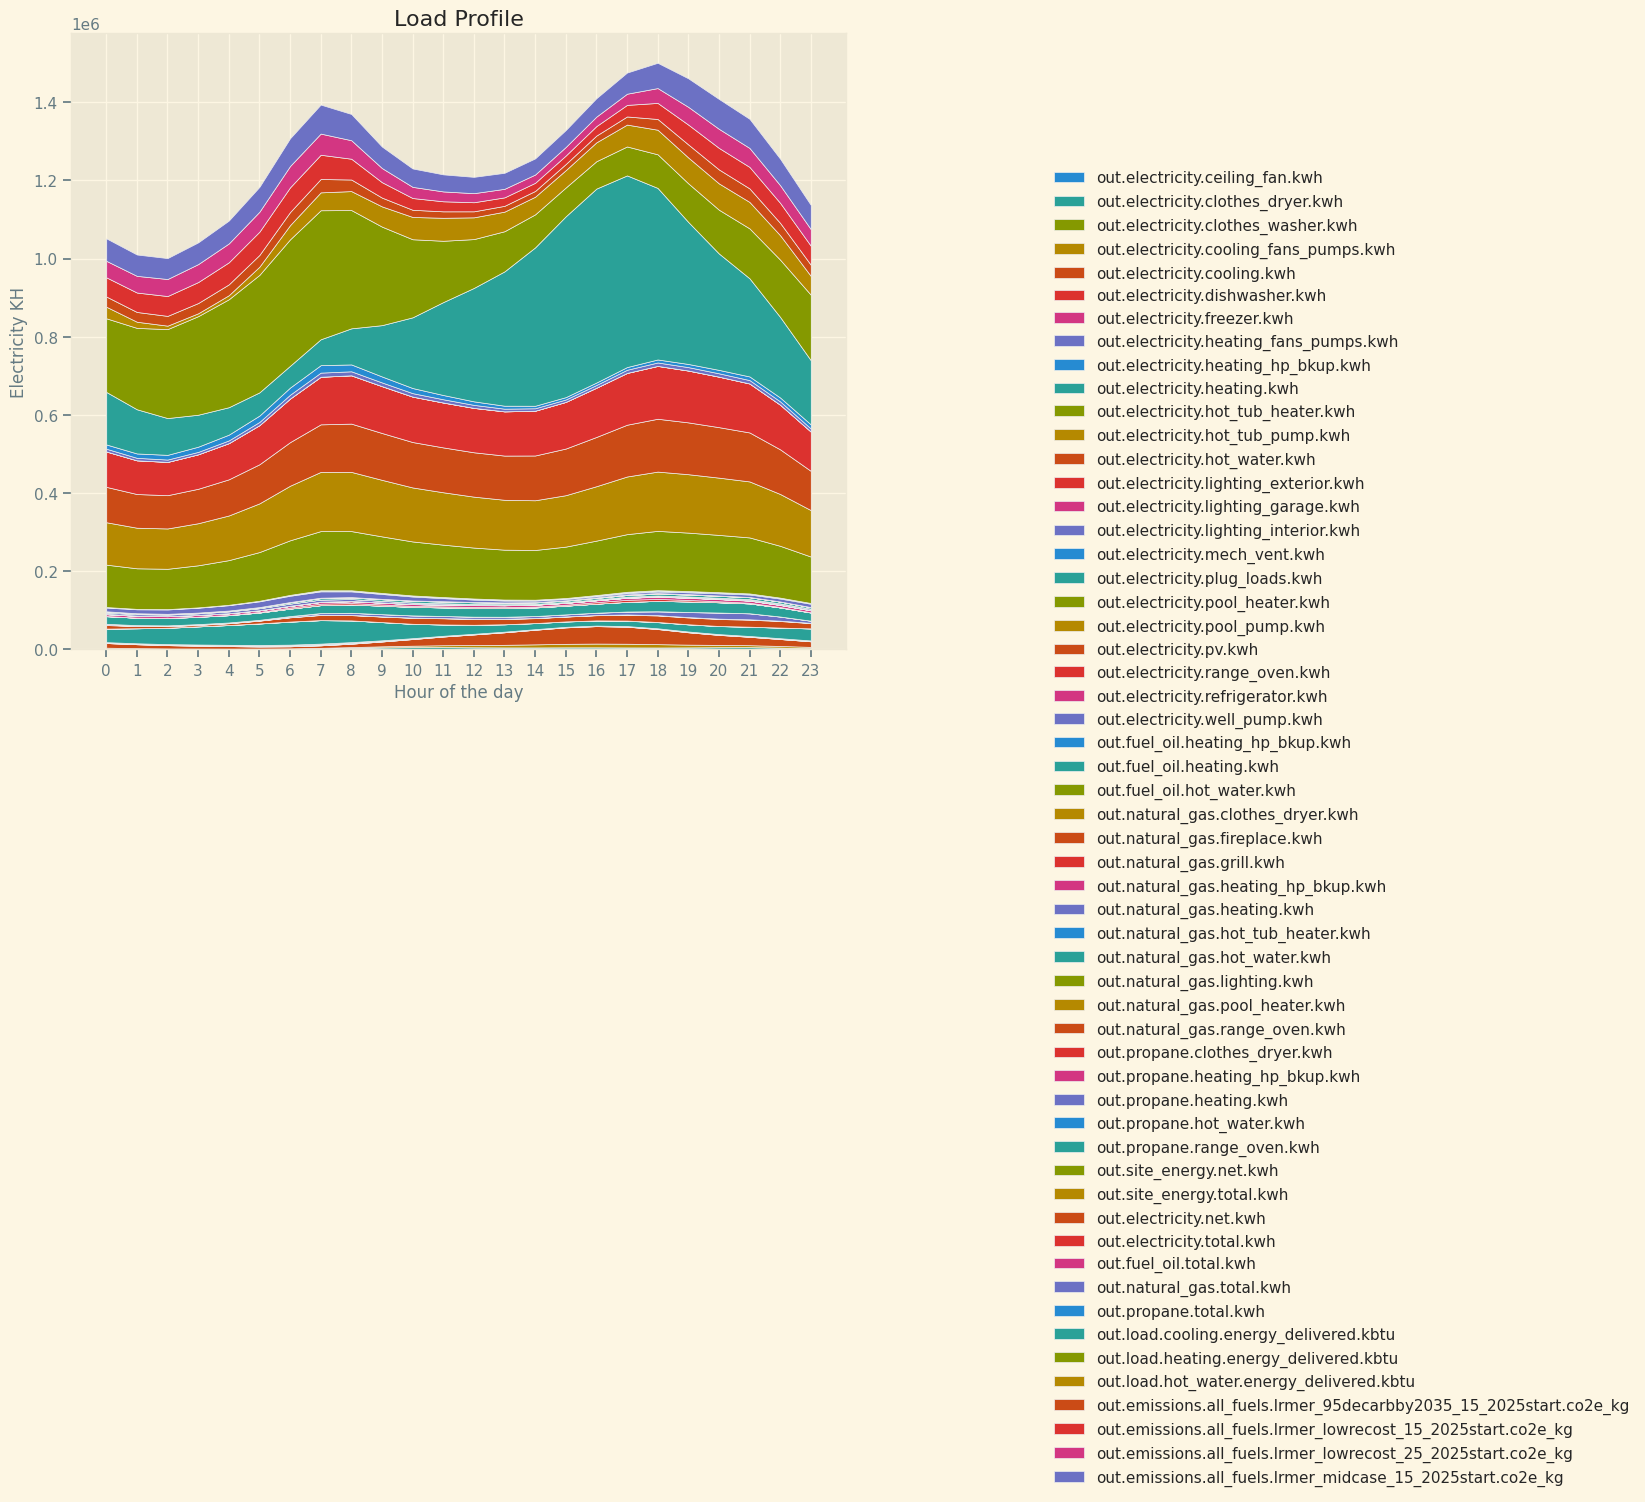

In [60]:
# plotting the average of ALl
plt.style.use('Solarize_Light2')
Labels=[n for n in grouped_average.columns if n not in['Hours','units_represented']]
usage=list(grouped_average.select(pl.all().exclude('Hours', 'units_represented')))

fig, ax=plt.subplots(1,1,figsize=(10,8))
ax.stackplot(grouped_average['Hours'], usage, labels=Labels)
ax.legend(loc='upper left', bbox_to_anchor=(1.25,0.8), frameon=False)
ax.set_xticks(list(range(0,24)))
ax.set_xlabel('Hour of the day')
ax.set_ylabel('Electricity KH')
ax.set_title('Load Profile')
plt.show()

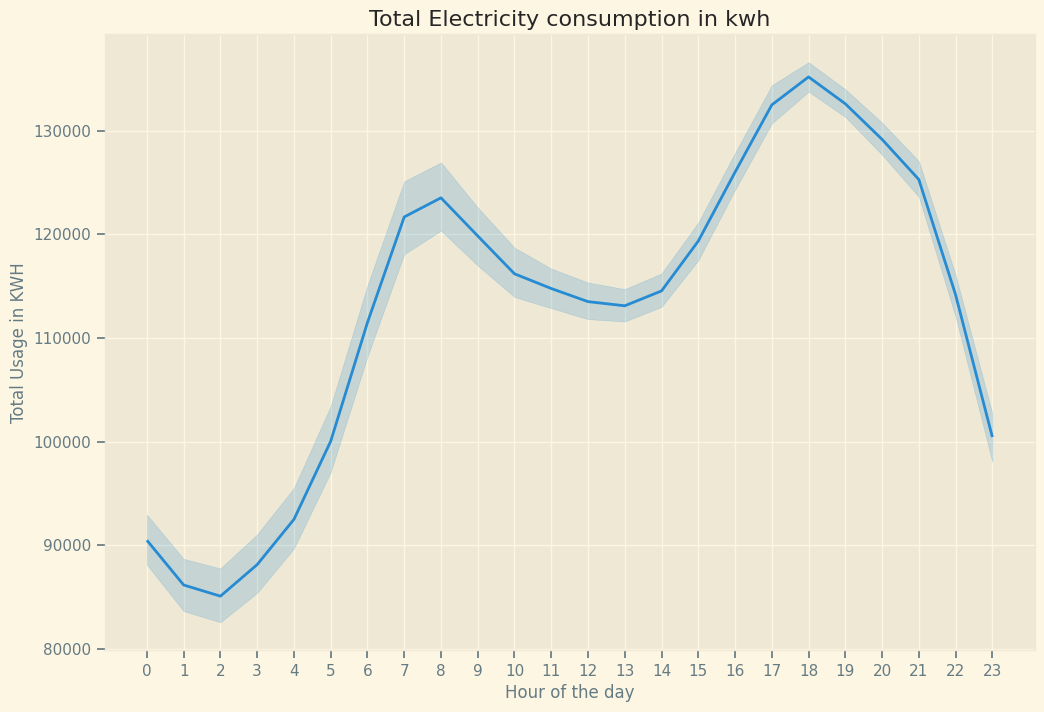

In [61]:
# visualize the total electricity usage
fig, ax=plt.subplots(1,1,figsize=(12,8))
sns.lineplot(data, x="Hours", y='out.electricity.total.kwh')
ax.set_title("Total Electricity consumption in kwh")
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Total Usage in KWH")
ax.set_xticks(list(range(0,24)))
plt.show()